## Computing  $\pi$ with Monte Carlo Methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Compute  the value of $\pi$ by randomly throwing N points onto a square with sides of 2 cm, inside which a circle of radius 1 cm is inscribed. The ratio between the area of the circle and the area of the square will tend to be equal to the number of points inside the circle divided by the total number of points.

In [2]:
def mc_pi_aprox(N):
    x, y = np.random.uniform(-1, 1, size=(2, N))
    interior = (x**2 + y**2) <= 1
    pi = interior.sum() * 4 / N
    return pi, x, y, interior

### Plotting the points outside and inside the circel

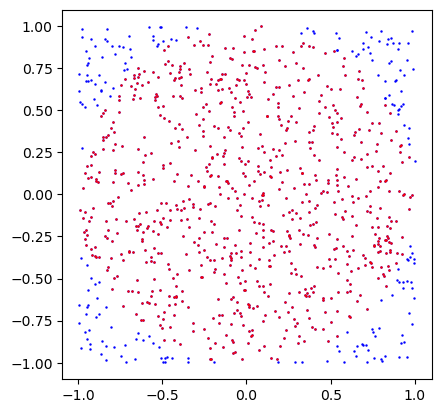

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

In [3]:
resultado=mc_pi_aprox(1000)
pi=resultado[0]
#plt.figure()
plt.plot(resultado[1],resultado[2],'b.',markersize=1.5)
plt.plot(resultado[1][resultado[3]],resultado[2][resultado[3]],'r.',markersize=1.5)
#plt.plot(0, 0, label='$\hat \pi$ = {:4.4f}'
#             .format(pi), alpha=0)
plt.axis('square')
#plt.legend(frameon=True, framealpha=0.9, fontsize=16)
#mc_pi_aprox(10000)
plt.show()
plt.close

 #### The estimation of $\pi$ is repeated with N points a number of times equal to Npruebas, and the mean value and standard deviation of the sample are calculated.

In [4]:
def getEst(Npuntos,Npruebas):
    res=[]
    for i in range(Npruebas):
        res.append(mc_pi_aprox(Npuntos)[0])
    res=np.array(res)
    mu=np.mean(res)
    std=np.std(res)
    return mu,std

#### Exercise 1: For a fixed value of Npruebas, calculate the value of $\pi$ such that the standard deviation is less than $10^{-5}$.

In [5]:
def getEst_fast(Npuntos, Npruebas): # Operaciones vectorizadas para optimizar un poco.
    x = np.random.uniform(-1, 1, size=(Npruebas, Npuntos))
    y = np.random.uniform(-1, 1, size=(Npruebas, Npuntos))
    interior = (x**2 + y**2) <= 1
    pis = 4 * interior.sum(axis=1) / Npuntos
    mu = pis.mean()
    std = pis.std()
    return mu, std

getEst_fast(100000,100)

# Not enough... too slow

(np.float64(3.1407168000000003), np.float64(0.004550568070032568))

This way of estimating pi has a slow convergece in terms of $N$. In particular, the std scales as:
$$ \sigma' = \frac{\sigma}{\sqrt N} $$

So, for example if I want to improve $\sigma$ from $10^{-3}$ (which I already have for $N=10^{5}, N_{pruebas}=100$) to $\sigma = 10^{-5}$, I need $10^4$ more random points which adds a lot of computational time.


One way of improving convergence is to apply quasi MonteCarlo approach. QMC Basically uses non random distributed points that are well distributed over the domain space. In particular, I implemented a Sobol sequence (works well with this 2D Pi stimation problem) which minimizes the difference between the real density of points and the ideal uniform distribution. 

In [6]:
from scipy.stats import qmc

def getEst_fast_qmc_vec(Npuntos, Npruebas, tol=1e-5):
    sobol_engine = qmc.Sobol(d=2, scramble=True)
    puntos = sobol_engine.random(n=Npuntos * Npruebas)  
    puntos = 2*puntos - 1 

    puntos = puntos.reshape(Npruebas, Npuntos, 2)
    x = puntos[:,:,0]
    y = puntos[:,:,1]

    # Chequeo dentro del círculo
    interior = (x**2 + y**2) <= 1
    pi_array = 4 * interior.sum(axis=1) / Npuntos

    mu = pi_array.mean()
    std = pi_array.std()
    tol_met = std < tol

    return mu, std, tol_met

mu, std, tol_met = getEst_fast_qmc_vec(1000000, 10)
print("Estimación de pi:", mu)
print("Desviación estándar:", std)
print("Cumple tolerancia 1e-5?:", tol_met)


c:\Users\diego\miniconda3\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Estimación de pi: 3.1415844
Desviación estándar: 6.679999999994987e-05
Cumple tolerancia 1e-5?: False


This approach achieved $\sigma \sim 10^{-6}$ in around 6 minutes in my laptop employing $N=10^8$.

#### Exercise 2: Calcuate the integral of the function f(x)=sin(x) from 0 to pi/2 using the a Monte Carlo method similar to the one used to estimate $\pi$


#### Computation of an integral using a Markov Chain Monte Carlo Method

In [8]:

# Parameters
a, b = 0, np.pi/2
F_max = 1.0  # max value of sin(x) in [0, pi]
N_steps = 100000

# Initialize Markov chain
x, y = np.random.uniform(a, b), np.random.uniform(0, F_max)
N_hits = 0

for _ in range(N_steps):
    # Propose new point
    dx = np.random.normal(0, 0.1)
    dy = np.random.normal(0, 0.1)
    x_new = x + dx
    y_new = y + dy

    # Check bounds
    if a <= x_new <= b and 0 <= y_new <= F_max:
        x, y = x_new, y_new
        # Hit or miss
        if y < np.sin(x):
            N_hits += 1
    # If out of bounds, stay at current position

# Estimate integral
integral = (b - a) * F_max * N_hits / N_steps
print(f"Estimated integral of sin(x) from 0 to pi (Markov chain): {integral}")

Estimated integral of sin(x) from 0 to pi (Markov chain): 0.8714306782160047


#### Exercise: Calculate the $\int_0^2 e^{-2 x} \cos(x) dx$ i) with naive MonteCarlo ii) with importance sampling

In [9]:
a, b = 0.0, 2.0

N = 200000

x = np.random.uniform(a, b, size=N)

fx = np.exp(-2*x) * np.cos(x)

I_est = (b - a) * np.mean(fx)

std = np.std((b - a) * fx, ddof=1)
stderr = std / np.sqrt(N)

print(f"Integral estimada (Monte Carlo): {I_est:.6f} ± {stderr:.6f}")


Integral estimada (Monte Carlo): 0.405728 ± 0.001193


In [ ]:
def f(x):
    return np.exp(-2*x) * np.cos(x)

a, b = 0.0, 2.0
N = 200000

norm_const = 1 - np.exp(-2 * b)

u = np.random.rand(N)
x = - (1/2) * np.log(1 - u * norm_const) 

p_x = 2 * np.exp(-2 * x) / norm_const
g_over_p = f(x) / p_x  # f(x)/p(x)

I_est = np.mean(g_over_p)
std = np.std(g_over_p, ddof=1)
stderr = std / np.sqrt(N)

print(f"Monte Carlo con Importance Sampling: {I_est:.6f} ± {stderr:.6f}")


Monte Carlo con Importance Sampling: 0.406345 ± 0.000287
